Clustering Minggu ke-10

## Import Library dan Load Data

In [149]:
import pandas as pd
import re
import string
import nltk
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA, LatentDirichletAllocation

In [150]:
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [151]:
# Konfigurasi plot
%matplotlib inline
sns.set_style("whitegrid")

In [152]:
# LOAD DATA
df = pd.read_csv("../Klasifikasi/Dataset250Labeled.csv")
df

,full_text,clean_text,normalisasi_text,tokenize,stopword_removal,steming_data,label
0,@CakKhum Satu lagi mentri laknatullah alaih......,cakkhum satu lagi mentri laknatullah alaih uru...,cakkhum satu lagi mentri laknatullah alaih uru...,"['cakkhum', 'satu', 'lagi', 'mentri', 'laknatu...","['cakkhum', 'mentri', 'laknatullah', 'alaih', ...",cakkhum tri laknatullah alaih urus etanol koru...,negative
1,Udah di oplos Ada etanol Harga naik Dan pertam...,udah oplos etanol harga naik pertamina tetap r...,sudah oplos etanol harga naik pertamina tetap ...,"['sudah', 'oplos', 'etanol', 'harga', 'naik', ...","['oplos', 'etanol', 'harga', 'pertamina', 'rug...",oplos etanol harga pertamina rugi angkasa bobrok,negative
2,Tertibkan dong @pertamina jangan rusuh etanol aja,tertibkan dong pertamina jangan rusuh etanol,tertibkan dong pertamina jangan rusuh etanol,"['tertibkan', 'dong', 'pertamina', 'jangan', '...","['tertibkan', 'pertamina', 'rusuh', 'etanol']",tertib pertamina rusuh etanol,negative
3,Rieke Diah Pitaloka mempertanyakan kesiapan Pe...,rieke diah pitaloka mempertanyakan kesiapan pe...,rieke diah pitaloka mempertanyakan kesiapan pe...,"['rieke', 'diah', 'pitaloka', 'mempertanyakan'...","['rieke', 'diah', 'pitaloka', 'kesiapan', 'per...",rieke diah pitaloka kesiap pertamina serap eta...,negative
4,@susno2g @pertamina @Kemenperin_RI @Kementeria...,susnog pertamina kemenperinri kementerianesdm ...,susnog pertamina kemenperinri kementerianesdm ...,"['susnog', 'pertamina', 'kemenperinri', 'kemen...","['susnog', 'pertamina', 'kemenperinri', 'kemen...",susnog pertamina kemenperinri kementerianesdm ...,negative
...,...,...,...,...,...,...,...
245,Aku kangen pertamina hiks,kangen pertamina hiks,kangen pertamina hiks,"['kangen', 'pertamina', 'hiks']","['kangen', 'pertamina', 'hiks']",kangen pertamina hiks,positive
246,@AzzamAlifAditya Ekonomi masyarakat terus meni...,azzamalifaditya ekonomi masyarakat terus menin...,azzamalifaditya ekonomi masyarakat terus menin...,"['azzamalifaditya', 'ekonomi', 'masyarakat', '...","['azzamalifaditya', 'ekonomi', 'masyarakat', '...",azzamalifaditya ekonomi masyarakat tingkat kil...,positive
247,@Indranata_Tama Good job Kilang Pertamina Inte...,indranatatama good kilang pertamina internasional,indranatatama good kilang pertamina internasional,"['indranatatama', 'good', 'kilang', 'pertamina...","['indranatatama', 'good', 'kilang', 'pertamina...",indranatatama good kilang pertamina internasional,positive
248,@Indranata_Tama Kilang Pertamina Internasional...,indranatatama kilang pertamina internasional t...,indranatatama kilang pertamina internasional t...,"['indranatatama', 'kilang', 'pertamina', 'inte...","['indranatatama', 'kilang', 'pertamina', 'inte...",indranatatama kilang pertamina internasional baik,positive


Karena data dataset250labeled sudah bersih, maka digunakan kolom terkahir dari file dataset250labeled250 yaitu steming_data yang berarti data sudah selesai dilakukan pre-processing

## Elbow Methods

In [153]:
# 1. Mengubah teks menjadi angka menggunakan TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=1000)
tfidf_matrix = tfidf_vectorizer.fit_transform(df['steming_data'])


In [154]:
# 2. Mencari jumlah cluster optimal dengan Elbow Method
inertia = []
range_k = range(2, 11)

for k in range_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(tfidf_matrix)
    inertia.append(kmeans.inertia_)


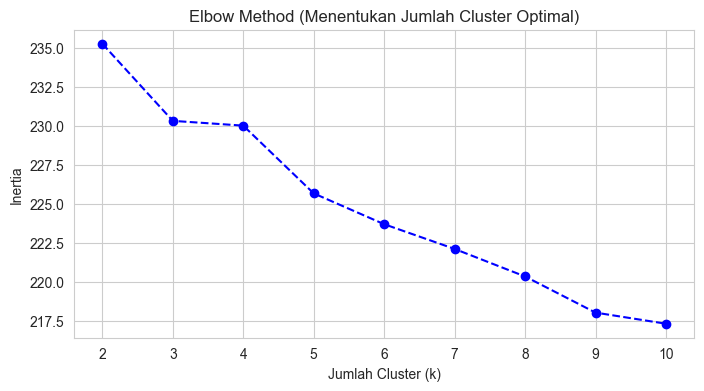

In [155]:
# 3. Plot Elbow
# Visualisasi Elbow
plt.figure(figsize=(8, 4))
plt.plot(range_k, inertia, marker='o', linestyle='--', color='b')
plt.title('Elbow Method (Menentukan Jumlah Cluster Optimal)')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

## Model Kmeans

In [156]:
# 1. Fit Model K-Means
jumlah_cluster = 3  # Ubah sesuai hasil Elbow Method
kmeans = KMeans(n_clusters=jumlah_cluster, random_state=42, n_init=10)
kmeans.fit(tfidf_matrix)

,n_clusters,3
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [157]:
# 2. Masukkan label cluster ke DataFrame
df['cluster_kmeans'] = kmeans.labels_

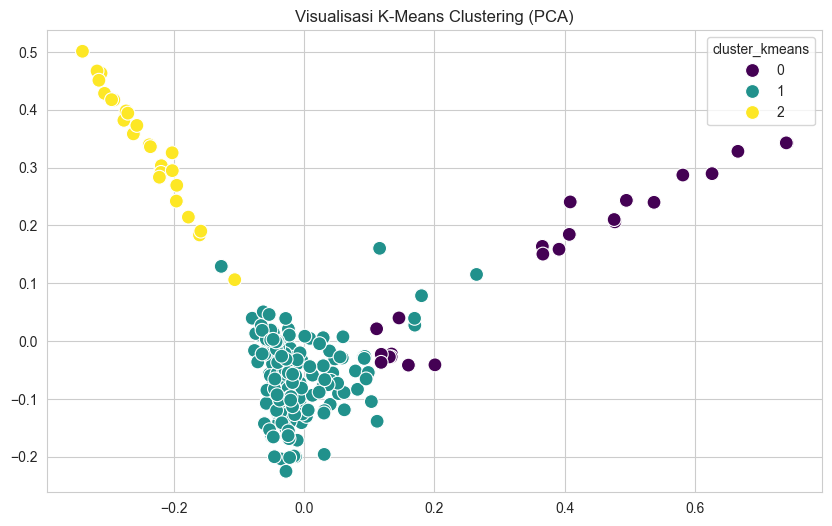

                                        steming_data  cluster_kmeans
0  cakkhum tri laknatullah alaih urus etanol koru...               1
1   oplos etanol harga pertamina rugi angkasa bobrok               1
2                      tertib pertamina rusuh etanol               1
3  rieke diah pitaloka kesiap pertamina serap eta...               1
4  susnog pertamina kemenperinri kementerianesdm ...               1
5  susnog pertamina kementerianesdm danantarari k...               1
6  snaipermask maksud etanol pertamina jelek ting...               1
7  pertamina kontol motor campur etanol bangsat c...               1
8  cangkeme sampeyan brebet lok nggo sepeda etano...               1
9  lanjut pertamina etanol pusing banget pakai ba...               1


In [158]:

# 3. Visualisasi Cluster menggunakan PCA (Reduksi dimensi ke 2D)
pca = PCA(n_components=2)
scatter_plot_points = pca.fit_transform(tfidf_matrix.toarray())

x_axis = scatter_plot_points[:, 0]
y_axis = scatter_plot_points[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_axis, y=y_axis, hue=df['cluster_kmeans'], palette='viridis', s=100)
plt.title('Visualisasi K-Means Clustering (PCA)')
plt.show()

# Lihat contoh data per cluster
print(df[['steming_data', 'cluster_kmeans']].head(10))

## Topic Modeling

In [159]:
# 1. Buat Document-Term Matrix (Count Vectorizer)
tf_vectorizer = CountVectorizer(max_features=1000, stop_words=list(stop_words))
tf_matrix = tf_vectorizer.fit_transform(df['clean_text'])

c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['baiknya', 'berkali', 'kali', 'kurangnya', 'mata', 'olah', 'sekurang', 'setidak', 'tama', 'tidaknya'] not in stop_words.
  warnings.warn(


In [160]:
# 2. Fit Model LDA
# n_components = jumlah topik yang ingin dicari
lda_model = LatentDirichletAllocation(n_components=3, random_state=42)
lda_model.fit(tf_matrix)

print("Model LDA berhasil dilatih!")

Model LDA berhasil dilatih!


In [161]:
def print_top_words(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        message = f"Topik #{topic_idx}: "
        message += " ".join([feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]])
        print(message)
    print()

print("--- Kata Kunci per Topik ---")
tf_feature_names = tf_vectorizer.get_feature_names_out()
print_top_words(lda_model, tf_feature_names, 10)

--- Kata Kunci per Topik ---
Topik #0: etanol pertamina pertalite kendaraan kandungan campuran mengandung pertamax aman spbu
Topik #1: pertamina etanol motor swasta pake bensin beli murni masyarakat biar
Topik #2: pertamina etanol kilang balikpapan internasional bahlil rdmp bensin ekonomi kalo



In [162]:
# Mendapatkan distribusi topik untuk setiap dokumen
topic_values = lda_model.transform(tf_matrix)

# Ambil topik dengan probabilitas tertinggi
df['dominant_topic'] = topic_values.argmax(axis=1)

# Tampilkan hasil akhir
df[['clean_text', 'cluster_kmeans', 'dominant_topic']].head()

,clean_text,cluster_kmeans,dominant_topic
0,cakkhum satu lagi mentri laknatullah alaih uru...,1,1
1,udah oplos etanol harga naik pertamina tetap r...,1,2
2,tertibkan dong pertamina jangan rusuh etanol,1,2
3,rieke diah pitaloka mempertanyakan kesiapan pe...,1,0
4,susnog pertamina kemenperinri kementerianesdm ...,1,0
